# Custom Operator Scaffold

This notebook shows how to write custom `abstractgraph` operators with the public scaffold helpers. The key choices are explicit: local vs global context, and node-induced vs edge-induced mapped subgraphs.

## Setup

In [1]:
from pathlib import Path
import runpy

BOOTSTRAP_CANDIDATES = (
    "notebooks/_bootstrap.py",
    "abstractgraph/notebooks/_bootstrap.py",
    "abstractgraph-ml/notebooks/_bootstrap.py",
    "abstractgraph-generative/notebooks/_bootstrap.py",
    "abstractgraph-graphicalizer/notebooks/_bootstrap.py",
)

_bootstrap_path = next(
    (
        candidate / relative
        for candidate in (Path.cwd(), *Path.cwd().parents)
        for relative in BOOTSTRAP_CANDIDATES
        if (candidate / relative).exists()
    ),
    None,
)
if _bootstrap_path is not None:
    runpy.run_path(str(_bootstrap_path))

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import networkx as nx
import numpy as np
from toolz import curry

from abstractgraph.graphs import graph_to_abstract_graph
from abstractgraph.display import display, display_graph
from abstractgraph.operators import (
    apply_global_node_decomposition,
    apply_local_edge_decomposition,
    apply_local_node_decomposition,
    forward_compose,
    get_directed_support,
    neighborhood,
)

## Example graph

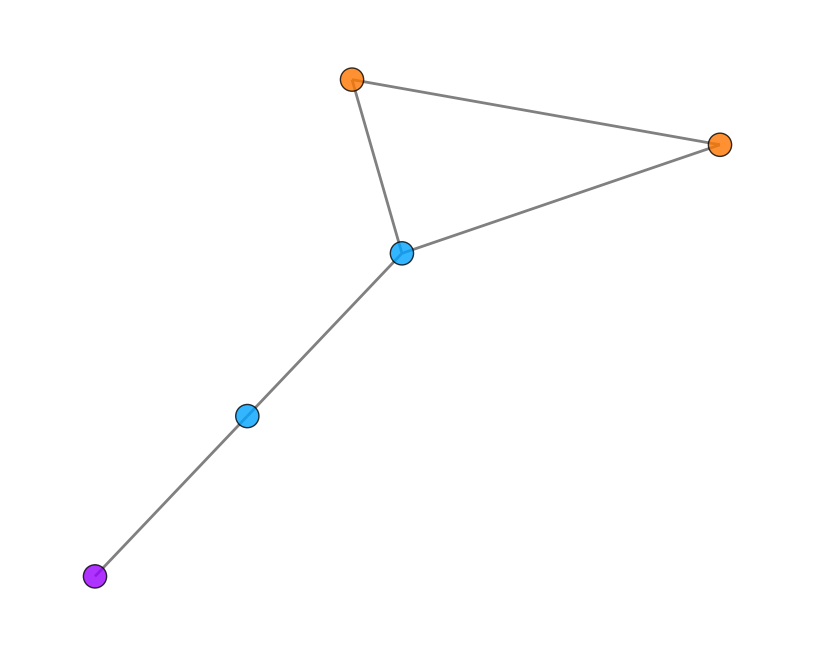

In [3]:
graph = nx.Graph()
graph.add_nodes_from(
    [
        ("A", {"label": "red", "attribute": np.array([1.0])}),
        ("B", {"label": "red", "attribute": np.array([1.0])}),
        ("C", {"label": "blue", "attribute": np.array([1.0])}),
        ("D", {"label": "blue", "attribute": np.array([1.0])}),
        ("E", {"label": "green", "attribute": np.array([1.0])}),
    ]
)
graph.add_edges_from(
    [
        ("A", "B", {"label": "same"}),
        ("B", "C", {"label": "cross"}),
        ("C", "D", {"label": "same"}),
        ("D", "E", {"label": "cross"}),
        ("A", "C", {"label": "cross"}),
    ]
)

display_graph(graph)

## Local node-induced operator

`apply_local_node_decomposition` calls the decomposition once per mapped subgraph. Each returned component is interpreted as a node set, so the resulting mapped subgraph is node-induced.

In [4]:
@curry
def high_degree_nodes(abstract_graph, min_degree=2):
    def decompose(subgraph):
        nodes = [node for node, degree in subgraph.degree() if degree >= min_degree]
        return [nodes]

    return apply_local_node_decomposition(
        abstract_graph,
        decompose,
        source_operator=high_degree_nodes,
        params={"min_degree": min_degree},
        skip_empty=True,
    )


high_degree_nodes.directed_support = "preserve"
get_directed_support(high_degree_nodes)

'preserve'

NodeDataView({0: {'mapped_subgraph': <networkx.classes.graph.Graph object at 0x14b1aec90>, 'label': 159, 'attribute': array([1.]), 'meta': {'source_function': 'high_degree_nodes', 'params': {'min_degree': 2}, 'source_chain': 'high_degree_nodes', 'parent_mapped_subgraph': <networkx.classes.graph.Graph object at 0x14b1ae510>}}})

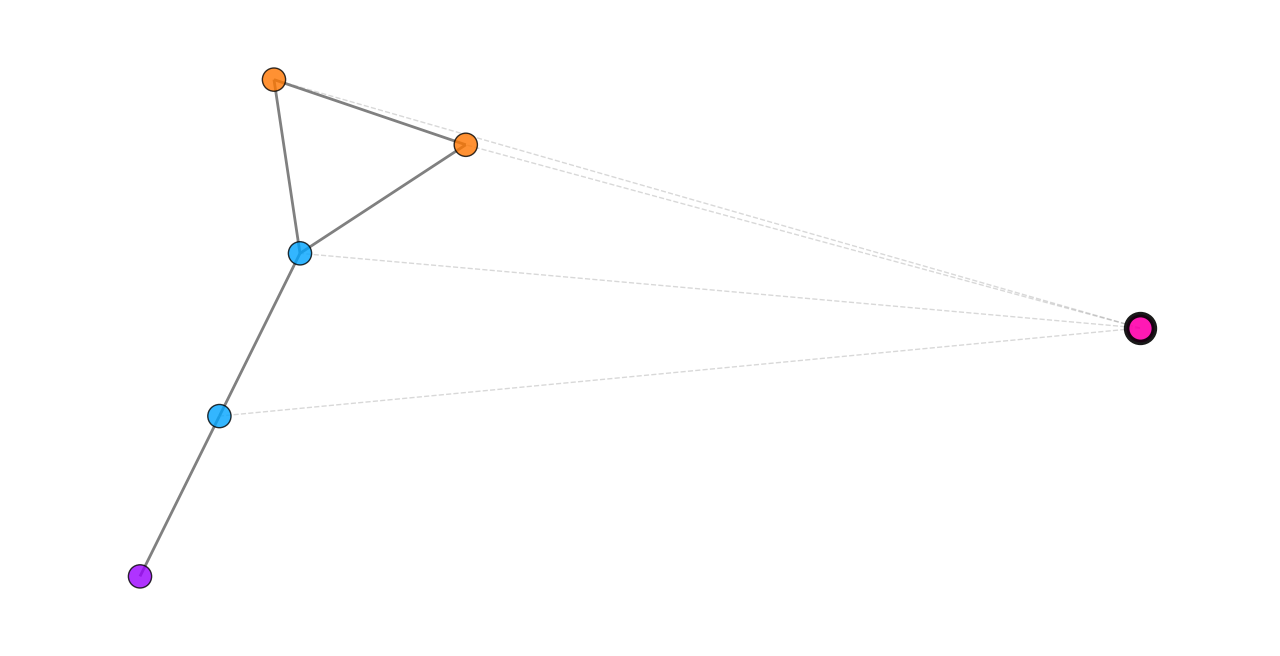

In [5]:
ag = graph_to_abstract_graph(graph, decomposition_function=high_degree_nodes(min_degree=2), nbits=8)
display(ag, size=(8, 4))
ag.interpretation_graph.nodes(data=True)

## Local edge-induced operator

`apply_local_edge_decomposition` materializes edge-induced mapped subgraphs. This matters when the selected edges do not include every edge between the selected nodes.

In [6]:
@curry
def same_label_edges(abstract_graph):
    def decompose(subgraph):
        edges = [
            (u, v)
            for u, v in subgraph.edges()
            if subgraph.nodes[u].get("label") == subgraph.nodes[v].get("label")
        ]
        return [edges]

    return apply_local_edge_decomposition(
        abstract_graph,
        decompose,
        source_operator=same_label_edges,
        skip_empty=True,
    )


same_label_edges.directed_support = "preserve"

[[('A', 'B'), ('C', 'D')]]

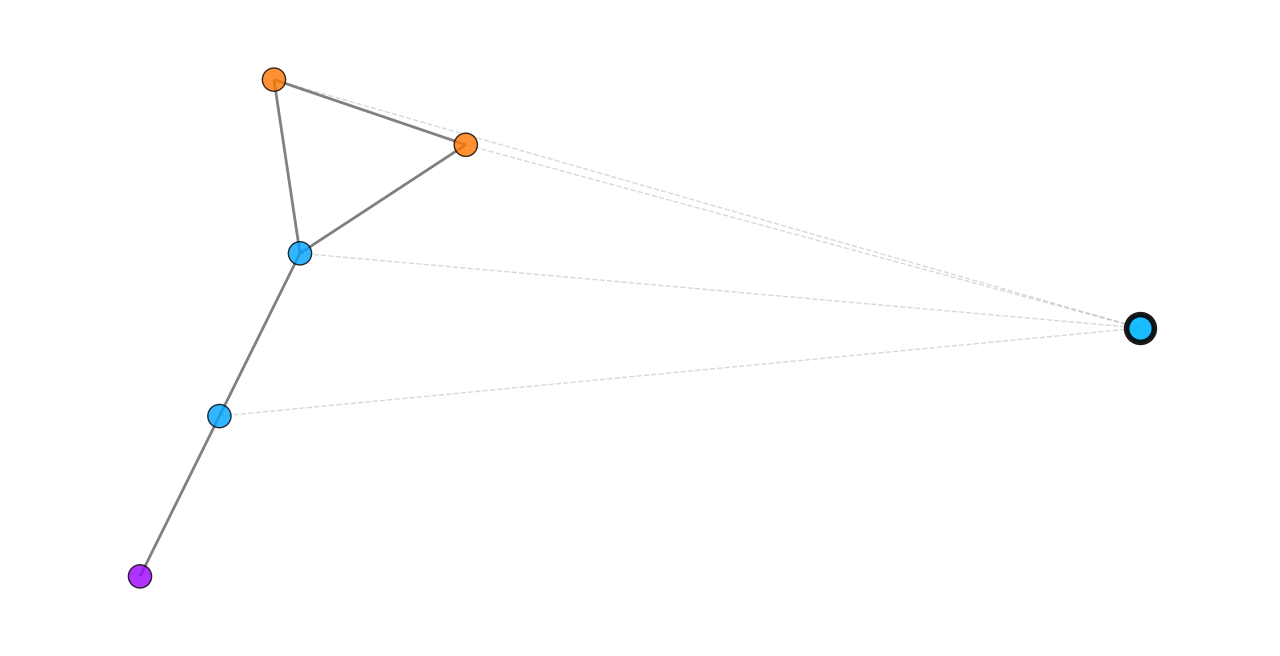

In [7]:
ag = graph_to_abstract_graph(graph, decomposition_function=same_label_edges(), nbits=8)
display(ag, size=(8, 4))
[list(mapped.edges()) for mapped in ag.get_interpretation_nodes_mapped_subgraphs()]

## Global node-induced operator

`apply_global_node_decomposition` receives all mapped subgraphs at once. Use it when the operator needs relationships across the current interpretation set.

In [8]:
@curry
def nodes_seen_in_multiple_subgraphs(abstract_graph, min_count=2):
    def decompose(subgraphs, base_graph):
        counts = {node: 0 for node in base_graph.nodes()}
        for subgraph in subgraphs:
            for node in subgraph.nodes():
                counts[node] += 1
        return [[node for node, count in counts.items() if count >= min_count]]

    return apply_global_node_decomposition(
        abstract_graph,
        decompose,
        source_operator=nodes_seen_in_multiple_subgraphs,
        params={"min_count": min_count},
        skip_empty=True,
    )


nodes_seen_in_multiple_subgraphs.directed_support = "preserve"

<Axes: >

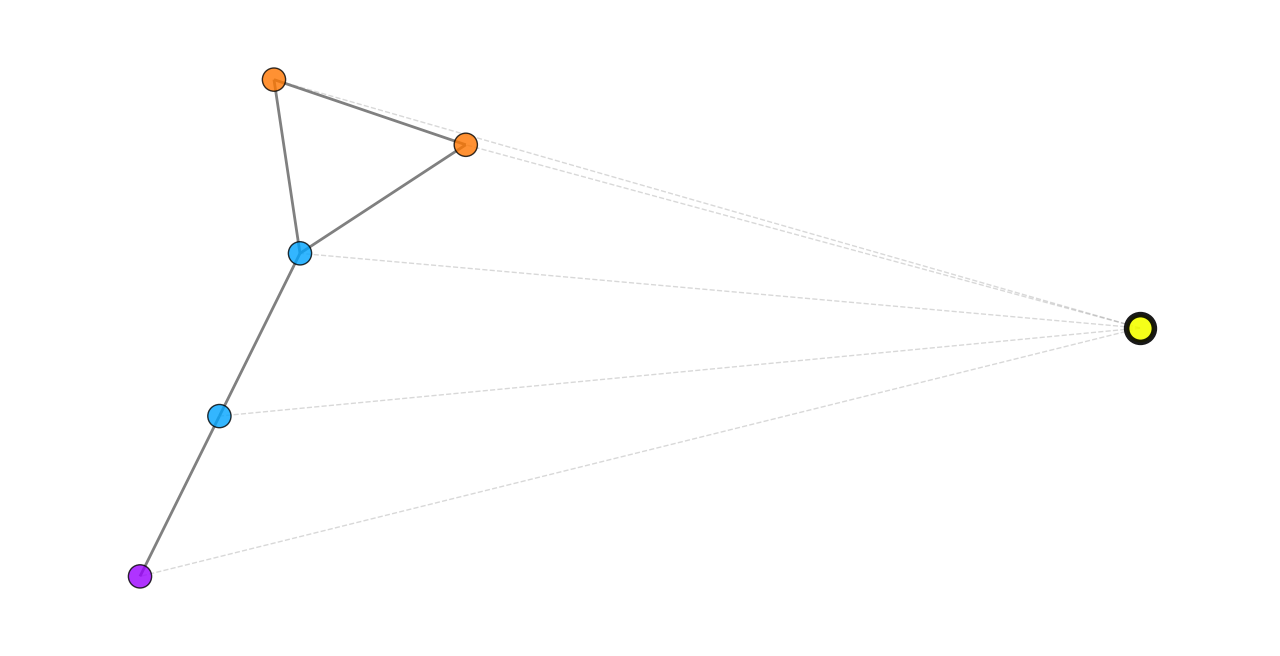

In [9]:
workflow = forward_compose(
    neighborhood(radius=1),
    nodes_seen_in_multiple_subgraphs(min_count=2),
)

ag = graph_to_abstract_graph(graph, decomposition_function=workflow, nbits=8)
display(ag, size=(8, 4))

## Directed graph operator

A directed custom operator can use the same scaffold. The decomposition function should call directed NetworkX APIs when edge orientation matters. This example keeps nodes with outgoing degree at least `min_out_degree`.

In [10]:
@curry
def high_out_degree_nodes(abstract_graph, min_out_degree=1):
    def decompose(subgraph):
        if not subgraph.is_directed():
            nodes = [node for node, degree in subgraph.degree() if degree >= min_out_degree]
        else:
            nodes = [
                node
                for node, out_degree in subgraph.out_degree()
                if out_degree >= min_out_degree
            ]
        return [nodes]

    return apply_local_node_decomposition(
        abstract_graph,
        decompose,
        source_operator=high_out_degree_nodes,
        params={"min_out_degree": min_out_degree},
        skip_empty=True,
    )


high_out_degree_nodes.directed_support = "directed"
get_directed_support(high_out_degree_nodes)

'directed'

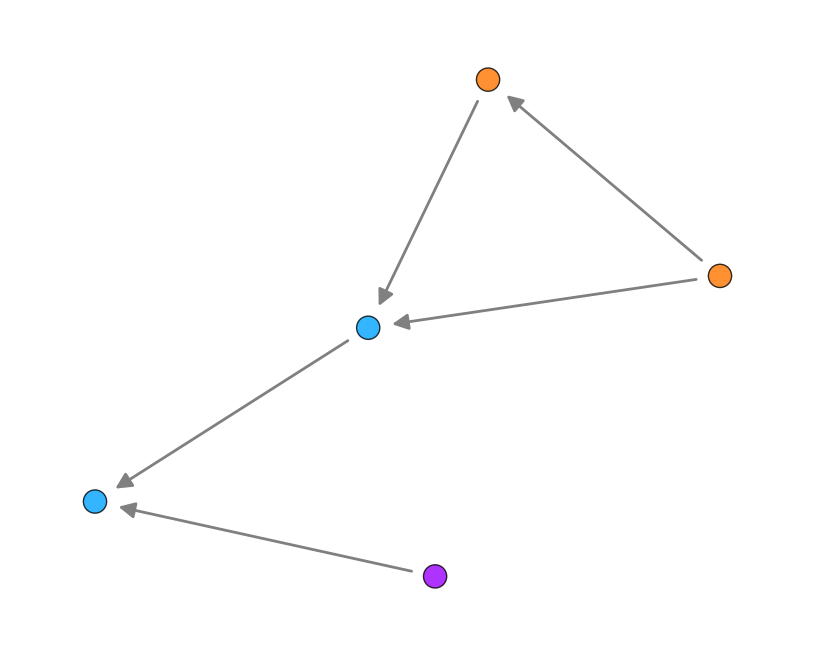

[['A']]

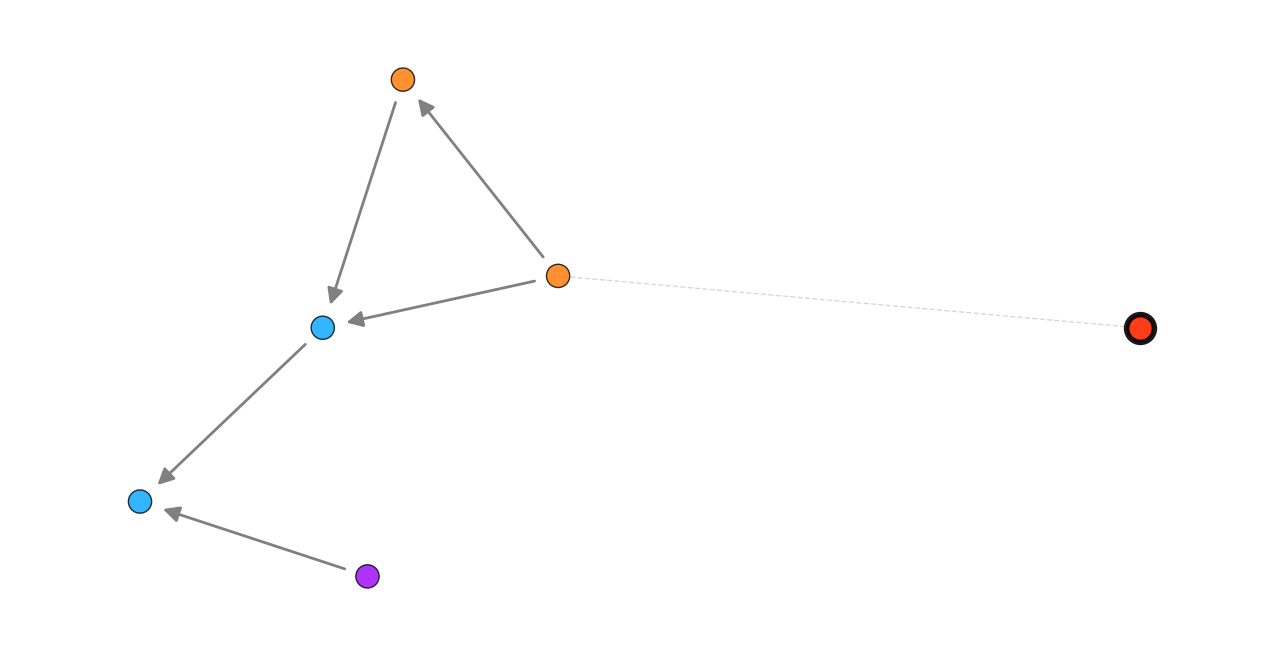

In [11]:
oriented_graph = nx.DiGraph()
oriented_graph.add_nodes_from((node, data.copy()) for node, data in graph.nodes(data=True))
oriented_graph.add_edge("A", "B", label="same")
oriented_graph.add_edge("A", "C", label="cross")
oriented_graph.add_edge("B", "C", label="cross")
oriented_graph.add_edge("C", "D", label="same")
oriented_graph.add_edge("E", "D", label="cross")

display_graph(oriented_graph)
ag = graph_to_abstract_graph(
    oriented_graph,
    decomposition_function=high_out_degree_nodes(min_out_degree=2),
    nbits=8,
)
display(ag, size=(8, 4))
[list(mapped.nodes()) for mapped in ag.get_interpretation_nodes_mapped_subgraphs()]

## Directed support

<Axes: >

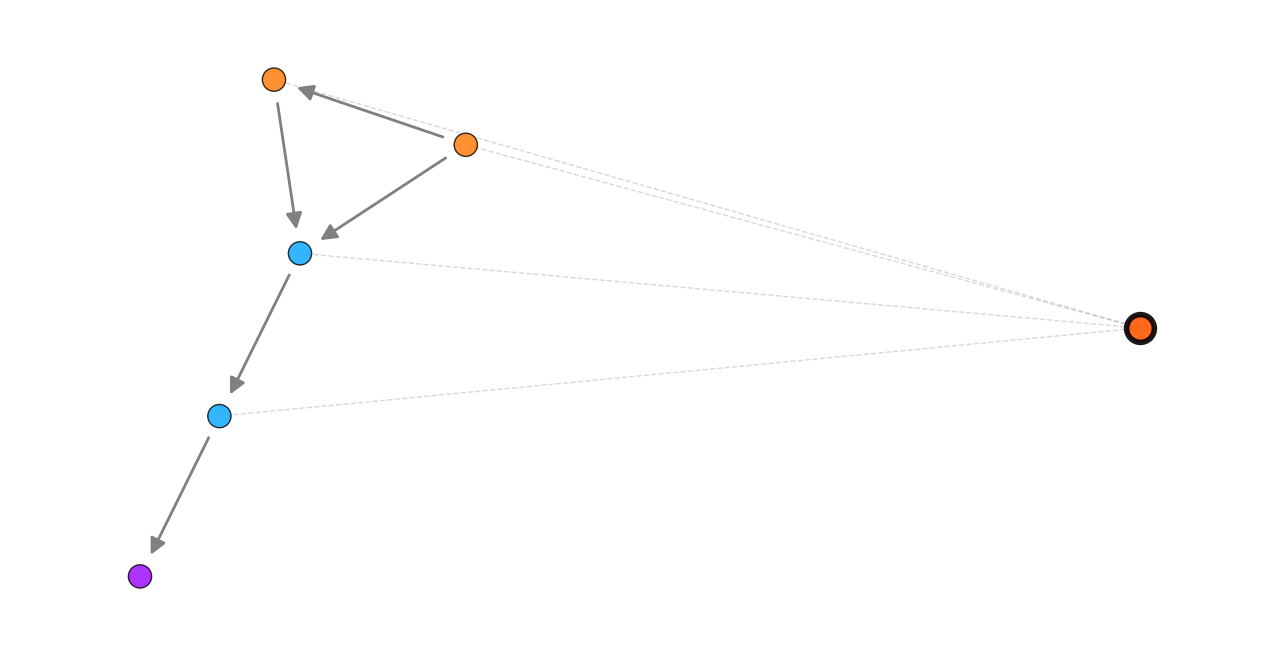

In [12]:
directed_graph = nx.DiGraph()
directed_graph.add_nodes_from((node, data.copy()) for node, data in graph.nodes(data=True))
directed_graph.add_edges_from(graph.edges(data=True))

ag = graph_to_abstract_graph(directed_graph, decomposition_function=high_degree_nodes(min_degree=2), nbits=8)
display(ag, size=(8, 4))

In [13]:
@curry
def undirected_only_example(abstract_graph):
    return apply_local_node_decomposition(
        abstract_graph,
        lambda subgraph: [list(subgraph.nodes())],
        source_operator=undirected_only_example,
    )


undirected_only_example.directed_support = "undirected_only"

try:
    graph_to_abstract_graph(directed_graph, decomposition_function=undirected_only_example(), nbits=8)
except ValueError as exc:
    print(exc)

Operator `undirected_only_example` supports only undirected base graphs.
